# Unidad 8 · Simulación de Monte Carlo y modelamiento avanzado

**Qué vas a aprender**
- Qué es una simulación de **Monte Carlo** y por qué funciona.
- Un modelo **estocástico** clásico, el movimiento browniano geométrico, y sus límites.
- Generar **escenarios de mercado** de cuatro formas y **comparar** lo que dice cada una del riesgo.
- Simular una **cartera** de varias monedas a la vez y una **cuenta de trading**.

**Qué tiene que ver con la app.** En **Tiempos duros**, el piloto dice qué probabilidad tienes de caer
más de un 10 % o un 20 % durante el próximo mes. Lo calcula con 10 000 simulaciones que remuestrean
**bloques de días reales**. Aquí construyes esa simulación y la comparas con las alternativas.

In [1]:
#@title Preparación: ejecuta esta celda primero (▶). Carga los precios de Binance.
# Es la misma en todos los cuadernos. Cómo se construye se explica en la Unidad 1.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

ACTIVOS = ["BTC", "ETH", "SOL"]        # las monedas de la cartera de ejemplo del piloto
COLORES = {"BTC": "#F7931A", "ETH": "#627EEA", "SOL": "#9945FF"}
DESDE = "2020-01-01"                    # el piloto también mira desde 2020
HASTA = "2026-09-26"                    # fija las cifras del texto; None = hasta ayer
ANUAL = 365                             # las criptos cotizan todos los días del año
API = "https://data-api.binance.vision/api/v3/klines"   # api.binance.com bloquea Colab


def descargar(simbolo, desde=DESDE):
    """Velas diarias YA CERRADAS de SIMBOLO/USDT en Binance, 1000 por petición."""
    inicio = int(pd.Timestamp(desde, tz="UTC").timestamp() * 1000)
    filas = []
    while True:
        r = requests.get(API, params={"symbol": f"{simbolo}USDT", "interval": "1d",
                                      "startTime": inicio, "limit": 1000}, timeout=30)
        r.raise_for_status()
        lote = r.json()
        filas += lote
        if len(lote) < 1000:
            break
        inicio = lote[-1][0] + 1                      # la página siguiente empieza tras la última vela
    crudo = pd.DataFrame([f[:7] for f in filas],
                         columns=["apertura_ms", "open", "high", "low", "close", "volume", "cierre_ms"])
    crudo = crudo[crudo["cierre_ms"] < pd.Timestamp.now(tz="UTC").timestamp() * 1000]
    df = pd.DataFrame({"fecha": pd.to_datetime(crudo["apertura_ms"], unit="ms", utc=True)})
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = crudo[c].astype(float).to_numpy()
    return df.drop_duplicates("fecha").reset_index(drop=True)


def velas(simbolo):
    """Velas diarias del periodo de estudio: del CSV si ya está, si no de Binance (y lo guarda)."""
    archivo = f"{simbolo}USDT_1d.csv"
    hoy = pd.Timestamp.now(tz="UTC").normalize()
    fin = pd.Timestamp(HASTA, tz="UTC") if HASTA else hoy - pd.Timedelta(days=1)
    df = None
    if os.path.exists(archivo):
        df = pd.read_csv(archivo)
        df["fecha"] = pd.to_datetime(df["fecha"], utc=True)
    if df is None or df["fecha"].max() < fin:
        try:
            df = descargar(simbolo)
            df.to_csv(archivo, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
        except requests.RequestException as e:
            if df is None:
                raise RuntimeError(f"No pude descargar {simbolo} de Binance ({e}). Sube {archivo} "
                                   "(carpeta de datos de respaldo del curso) y repite.") from None
            print(f"Aviso: sin conexión con Binance; {archivo} llega solo al {df['fecha'].max():%d-%m-%Y}.")
    df = df[(df["fecha"] >= pd.Timestamp(DESDE, tz="UTC")) & (df["fecha"] <= fin)]
    return df.set_index("fecha")


def cierres(activos=ACTIVOS):
    """Cierres diarios, una columna por moneda: la tabla con la que trabaja el piloto."""
    return pd.DataFrame({a: velas(a)["close"] for a in activos})


print(f"Listo. Periodo de estudio: del {DESDE} al {HASTA or 'día de ayer'}.")

Listo. Periodo de estudio: del 2020-01-01 al 2026-09-26.


In [2]:
precios = cierres()
r = np.log(precios["BTC"]).diff().dropna()          # rendimientos log diarios de BTC
mu, sigma = r.mean(), r.std()
print(f"BTC: media diaria {mu:.4%}, desviación diaria {sigma:.2%} ({len(r)} días)")
gen = np.random.default_rng(42)                      # generador de azar con semilla: resultados repetibles

BTC: media diaria 0.1001%, desviación diaria 3.21% (2460 días)


## 1. La idea: muchos futuros posibles

No sabemos qué pasará, pero si tenemos un modelo de **cómo** se generan los rendimientos, podemos
sortear miles de futuros posibles y contar en cuántos pasa algo. La proporción se acerca a la
probabilidad verdadera a medida que crece el número de simulaciones (la **ley de los grandes
números**); el error baja como $1/\sqrt{n}$.

Ejemplo: ¿qué probabilidad hay de que BTC caiga más de un 20 % en 30 días, si sus rendimientos fueran
normales con la media y la desviación históricas?

In [3]:
for n in [100, 1_000, 10_000, 100_000]:
    caida = np.exp(gen.normal(mu, sigma, size=(n, 30)).sum(axis=1)) - 1
    p = (caida < -0.20).mean()
    print(f"{n:>7} simulaciones: {p:.2%}  (± {1.96 * np.sqrt(p * (1 - p) / n):.2%})")

    100 simulaciones: 10.00%  (± 5.88%)
   1000 simulaciones: 6.60%  (± 1.54%)
  10000 simulaciones: 7.14%  (± 0.50%)
 100000 simulaciones: 7.25%  (± 0.16%)


Con 100 simulaciones el resultado baila varios puntos; con 10 000, menos de medio punto. El piloto usa
10 000.

## 2. Un modelo estocástico: el movimiento browniano geométrico

El modelo de precios más usado (está detrás de la fórmula de Black-Scholes) supone que el log del precio
avanza cada día una cantidad **normal** e **independiente** de las anteriores:

$$\ln S_{t+1} = \ln S_t + \mu + \sigma\,Z_t,\qquad Z_t \sim N(0, 1)$$

Simulemos 10 000 trayectorias de BTC a un año desde el último cierre.

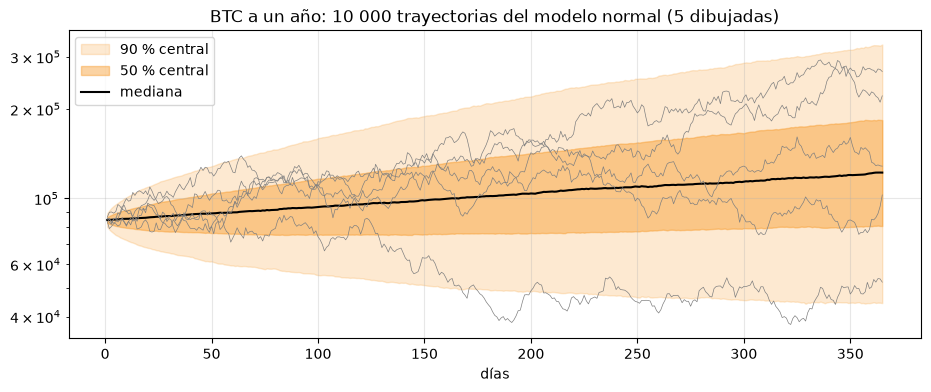

Dentro de un año: mediana +45%, 5 % peor -47%, 5 % mejor +291%; probabilidad de perder: 27%


In [4]:
S0 = precios["BTC"].iloc[-1]
dias = 365
caminos = S0 * np.exp(np.cumsum(gen.normal(mu, sigma, size=(10_000, dias)), axis=1))
percentiles = np.percentile(caminos, [5, 25, 50, 75, 95], axis=0)
eje = np.arange(1, dias + 1)
plt.figure(figsize=(11, 4))
plt.fill_between(eje, percentiles[0], percentiles[4], alpha=0.2, color=COLORES["BTC"], label="90 % central")
plt.fill_between(eje, percentiles[1], percentiles[3], alpha=0.4, color=COLORES["BTC"], label="50 % central")
plt.plot(eje, percentiles[2], color="black", label="mediana")
plt.plot(eje, caminos[:5].T, color="grey", linewidth=0.5)
plt.yscale("log"); plt.legend(); plt.title("BTC a un año: 10 000 trayectorias del modelo normal (5 dibujadas)")
plt.xlabel("días"); plt.show()
final = caminos[:, -1] / S0 - 1
print(f"Dentro de un año: mediana {np.median(final):+.0%}, 5 % peor {np.percentile(final, 5):+.0%},"
      f" 5 % mejor {np.percentile(final, 95):+.0%}; probabilidad de perder: {(final < 0).mean():.0%}")

El abanico es enorme: es lo que implica una volatilidad del 60 % anual. Pero el modelo tiene dos
supuestos que en cripto no se cumplen: los rendimientos **no son normales** (colas gruesas, Unidad 3) y
**no son independientes** en tamaño (la volatilidad viene en rachas, Unidad 6).

## 3. Cuatro formas de generar escenarios

| Método | Cómo sortea cada día | Qué conserva | Qué pierde |
|---|---|---|---|
| **normal** | $N(\mu, \sigma)$ con la media y la desviación históricas | media y varianza | colas gruesas y rachas |
| **normal con la volatilidad de hoy** | $N(\mu, \sigma_{EWMA})$ | el momento actual | colas gruesas y rachas |
| **bootstrap** | un día real al azar del historial | las colas | las rachas |
| **bootstrap por bloques** | trozos de 10 días reales seguidos | colas y rachas | — |

El bootstrap no supone ninguna distribución: los escenarios son trozos de la historia real. Por
bloques, además, conserva que un día malo suele venir con otros días malos.

In [5]:
def bloques(n_hist, dias, n, bloque, gen):
    """Matriz (n, dias) de índices de días históricos, en bloques de días seguidos (como el piloto)."""
    n_bloques = -(-dias // bloque)                                       # redondeo hacia arriba
    inicios = gen.integers(0, n_hist - bloque + 1, size=(n, n_bloques))
    return (inicios[:, :, None] + np.arange(bloque)).reshape(n, -1)[:, :dias]


def ewma_sigma(x, lam=0.94, arranque=30):
    v = np.var(x[:arranque])
    for xi in x:
        v = lam * v + (1 - lam) * xi ** 2
    return np.sqrt(v)


x = r.to_numpy()
n, dias = 10_000, 30
escenarios = {
    "normal": gen.normal(mu, sigma, size=(n, dias)),
    "normal, volatilidad de hoy": gen.normal(mu, ewma_sigma(x), size=(n, dias)),
    "bootstrap": x[gen.integers(0, len(x), size=(n, dias))],
    "bootstrap por bloques": x[bloques(len(x), dias, n, 10, gen)],
}


def medir(lr_dias):
    """Riesgo a 30 días de una simulación de rendimientos log diarios (n, dias)."""
    camino = np.exp(np.cumsum(lr_dias, axis=1))
    camino = np.hstack([np.ones((len(camino), 1)), camino])
    final = camino[:, -1] - 1
    caida = (camino / np.maximum.accumulate(camino, axis=1) - 1).min(axis=1)
    q5 = np.percentile(final, 5)
    return {"pérdida en el 5 % peor (VaR 95 %)": -q5, "pérdida media en ese 5 % (CVaR)": -final[final <= q5].mean(),
            "P(caer >10 % en algún momento)": (caida <= -0.10).mean(), "P(caer >20 % en algún momento)": (caida <= -0.20).mean(),
            "días de −10 % o peor, por cada 1000": (lr_dias < np.log(0.9)).mean() * 1000}


comparacion = pd.DataFrame({m: medir(v) for m, v in escenarios.items()}).T
comparacion["días de −10 % o peor, por cada 1000"] = comparacion["días de −10 % o peor, por cada 1000"].round(2)
print(f"En la historia real: {(x < np.log(0.9)).mean() * 1000:.2f} días de −10 % o peor por cada 1000")
comparacion.round(3)

En la historia real: 5.28 días de −10 % o peor por cada 1000


,pérdida en el 5 % peor (VaR 95 %),pérdida media en ese 5 % (CVaR),P(caer >10 % en algún momento),P(caer >20 % en algún momento),"días de −10 % o peor, por cada 1000"
normal,0.228,0.282,0.780,0.238,0.44
"normal, volatilidad de hoy",0.165,0.206,0.537,0.073,0.00
bootstrap,0.232,0.314,0.683,0.197,5.43
bootstrap por bloques,0.224,0.302,0.604,0.169,5.61


**Qué dice la comparación:**
- La **normal** casi no produce días de −10 %: 0,4 por cada 1000, frente a 5,3 en la historia real.
  Subestima las catástrofes de un día. A 30 días la diferencia se diluye (al sumar muchos días, las
  colas se suavizan), pero sigue en la **CVaR**: cuando el mes sale mal, la normal promete perder menos
  (28 %) que los días reales (30-31 %).
- Los dos **bootstrap** reproducen la frecuencia real de días malos, porque son días reales.
- **Por bloques** sale aquí algo menos de riesgo que con días sueltos: al copiar trozos reales, copia
  también los rebotes que siguen a las caídas (la ligera autocorrelación negativa de la Unidad 5) y las
  rachas de calma. Lo importante de los bloques no es que den más o menos riesgo, sino que no inventan
  una independencia que no existe.
- La **normal con la volatilidad de hoy** da mucho menos riesgo, porque hoy la EWMA (45 %) está por
  debajo de la media histórica (61 %). Es el único método que "sabe" en qué momento estamos; los demás
  miran toda la historia por igual.

## 4. Una cartera: simular todas las monedas a la vez

Con varias monedas hay que conservar su **correlación**: un día malo de BTC suele serlo también de ETH y
SOL. El bootstrap lo consigue sin esfuerzo: cada sorteo toma **el mismo día** para las tres monedas.

Con la cartera de ejemplo del piloto (0,05 BTC, 1,2 ETH, 10 SOL y 500 USDT), exactamente como lo hace
el piloto: rendimientos **simples** diarios de los días comunes, 10 000 caminos de 21 días (un mes de
negociación), bloques de 10 días y semilla 42. Las unidades no cambian durante el mes (quien no hace
nada).

In [6]:
unidades = pd.Series({"BTC": 0.05, "ETH": 1.2, "SOL": 10.0})
usdt = 500.0
comunes = precios.dropna()
R = comunes.pct_change().dropna()                     # rendimientos simples, mismos días para las tres


def proximo_mes(valores, efectivo, dias=21, n=10_000, bloque=10, semilla=42):
    """Caminos del valor de la cartera (empiezan en 1), como `motor.proximo_mes` del piloto."""
    total = valores.sum() + efectivo
    idx = bloques(len(R), dias, n, bloque, np.random.default_rng(semilla))
    crecimiento = np.cumprod(1 + R[valores.index].to_numpy()[idx], axis=1)   # (n, dias, monedas)
    caminos = (crecimiento @ valores.to_numpy() + efectivo) / total
    return np.hstack([np.ones((n, 1)), caminos])


def resumen(caminos):
    final = caminos[:, -1] - 1
    caida = (caminos / np.maximum.accumulate(caminos, axis=1) - 1).min(axis=1)
    return {"rentabilidad mediana": np.median(final), "pérdida en el 5 % peor": -np.percentile(final, 5),
            "P(caer >10 %)": (caida <= -0.10).mean(), "P(caer >20 %)": (caida <= -0.20).mean()}


valor_hoy = unidades * comunes.iloc[-1]
total = valor_hoy.sum() + usdt
# Siguiendo la recomendación del piloto (Unidad 6): min(1, 15 % / volatilidad EWMA de la mezcla), mismo reparto.
mezcla = valor_hoy / valor_hoy.sum()
sigma_mezcla = ewma_sigma((np.log(comunes).diff().dropna() @ mezcla).to_numpy()) * np.sqrt(ANUAL)
parte = min(1, 0.15 / sigma_mezcla)
print(f"Volatilidad prevista {sigma_mezcla:.1%} -> en cripto el {parte:.1%} del total")
valor_plan = mezcla * parte * total
efectivo_plan = total - valor_plan.sum()
tabla = pd.DataFrame({"con lo que tiene hoy": resumen(proximo_mes(valor_hoy, usdt)),
                      "siguiendo la recomendación": resumen(proximo_mes(valor_plan, efectivo_plan))})
tabla.round(3)

Volatilidad prevista 48.7% -> en cripto el 30.8% del total


,con lo que tiene hoy,siguiendo la recomendación
rentabilidad mediana,0.027,0.009
pérdida en el 5 % peor,0.202,0.066
P(caer >10 %),0.509,0.036
P(caer >20 %),0.121,0.000


Son las cifras de la tabla **"Un mal día y el próximo mes"** del piloto para esta cartera con los
cierres del 26-09-2026. Con lo que tiene hoy, la mitad de los escenarios cae más de un 10 % en algún
momento del mes, y uno de cada ocho, más de un 20 %. Siguiendo la recomendación, un 4 % y prácticamente
ninguno.

El piloto muestra también **"Un mal día (1 de cada 20)"**. Ese no es Monte Carlo: es una
**simulación histórica**, el percentil 5 de los rendimientos reales de la cartera en los últimos 730 días.

In [7]:
pesos = valor_hoy / total
x_cartera = (R.iloc[-730:] @ pesos).to_numpy()
q5 = np.quantile(x_cartera, 0.05)
print(f"Un mal día (1 de cada 20): perder {-q5:.2%} ({-q5 * total:,.0f} USDT)."
      f" Si se pasa, pierde de media {-x_cartera[x_cartera <= q5].mean():.2%}")

Un mal día (1 de cada 20): perder 4.02% (369 USDT). Si se pasa, pierde de media 5.89%


## 5. Caso aplicado: posibles trayectorias de la cartera a tres meses

El mismo bootstrap por bloques, a 90 días, con lo que tiene hoy y siguiendo la recomendación.

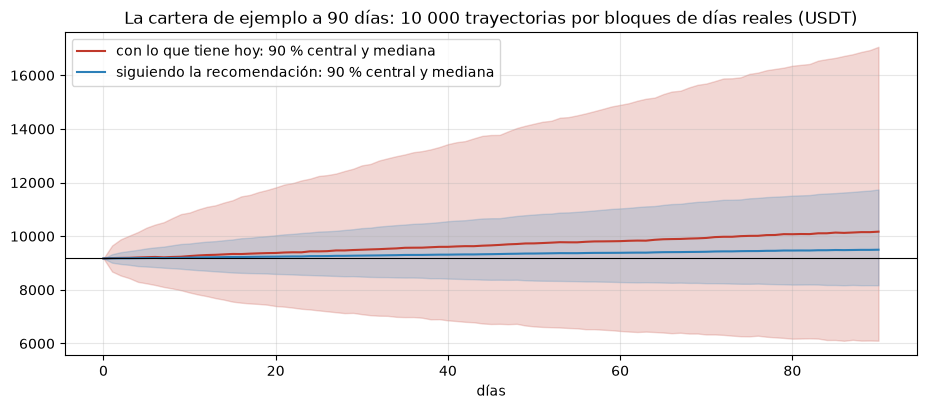

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.2))
for nombre, (v, e, color) in {"con lo que tiene hoy": (valor_hoy, usdt, "#c0392b"),
                              "siguiendo la recomendación": (valor_plan, efectivo_plan, "#2c7fb8")}.items():
    c = proximo_mes(v, e, dias=90) * total
    p5, p50, p95 = np.percentile(c, [5, 50, 95], axis=0)
    ax.fill_between(range(91), p5, p95, alpha=0.2, color=color)
    ax.plot(p50, color=color, label=f"{nombre}: 90 % central y mediana")
ax.axhline(total, color="black", linewidth=0.8)
ax.set_title("La cartera de ejemplo a 90 días: 10 000 trayectorias por bloques de días reales (USDT)")
ax.set_xlabel("días"); ax.legend(loc="upper left"); plt.show()

El piloto no promete ganar más: estrecha el abanico. Con lo que tiene hoy, el 5 % de los escenarios
peores deja la cartera muy por debajo de su valor; siguiendo la recomendación, la pérdida queda acotada.
A cambio, también se recorta la parte alta.

## 6. Otra trayectoria: la de una cuenta de trading

Monte Carlo también sirve para decisiones que no son de precios. Un operador con un sistema que acierta
el **45 %** de las veces y gana el doble de lo que arriesga cuando acierta (relación riesgo:beneficio
1:2) tiene una esperanza positiva: $0{,}45 \times 2 - 0{,}55 \times 1 = +0{,}35$ veces lo arriesgado por
operación. ¿Qué pasa en 200 operaciones si arriesga el 1 % de la cuenta cada vez? ¿Y el 10 %?

In [9]:
def cuenta(riesgo, n=10_000, operaciones=200, acierto=0.45, rb=2.0):
    gana = gen.random((n, operaciones)) < acierto
    factor = np.where(gana, 1 + riesgo * rb, 1 - riesgo)
    capital = np.hstack([np.ones((n, 1)), np.cumprod(factor, axis=1)])
    caida = (capital / np.maximum.accumulate(capital, axis=1) - 1).min(axis=1)
    return {"capital final mediano": np.median(capital[:, -1]), "P(perder dinero)": (capital[:, -1] < 1).mean(),
            "caída máxima mediana": np.median(caida), "P(caer más del 50 % por el camino)": (caida <= -0.5).mean()}


pd.DataFrame({f"arriesga el {int(x * 100)} %": cuenta(x) for x in [0.01, 0.02, 0.05, 0.10]}).T.round(3)

,capital final mediano,P(perder dinero),caída máxima mediana,P(caer más del 50 % por el camino)
arriesga el 1 %,1.967,0.000,-0.089,0.000
arriesga el 2 %,3.697,0.000,-0.176,0.000
arriesga el 5 %,18.834,0.001,-0.401,0.171
arriesga el 10 %,123.876,0.010,-0.671,0.942


Con la **misma** ventaja, arriesgar el 1 % deja una caída máxima mediana del 9 %. Arriesgar el 10 % da
una mediana final mucho mayor, pero el 94 % de las cuentas cae más de la mitad por el camino. Casi nadie aguanta eso sin abandonar. El tamaño de cada
apuesta decide la trayectoria tanto como la ventaja, y es la misma idea del piloto: **cuánto** expones
importa más que acertar la dirección.

## 7. Así lo usa el piloto

| Pantalla del piloto | Método | En este cuaderno |
|---|---|---|
| Próximo mes: P(caer más del 10 % / 20 %) | Monte Carlo, bootstrap por bloques de 10 días, 10 000 caminos de 21 días, semilla 42 | sección 4 |
| Un mal día (1 de cada 20) | simulación histórica: percentil 5 de los últimos 730 días | sección 4 |
| Si se repitiera lo peor | los peores tramos reales de 1, 7, 30, 90 y 365 días | Unidad 9 |
| 4 métodos de VaR (botón) | histórico, normal, t de Student y GARCH-t | Unidades 6 y 8 |

¿Por qué bloques y no la normal? Porque la normal casi no genera las caídas que de verdad ocurren
(sección 3), y una herramienta de riesgo que no ve las catástrofes da una tranquilidad falsa.

## Ejercicios

1. **El tamaño del bloque.** Repite la sección 4 con bloques de 1, 5, 20 y 60 días. ¿Cómo cambia la
   probabilidad de caer más de un 20 %? ¿Por qué con bloques de 1 día es el bootstrap simple?
2. **La semilla.** Cambia la semilla 42 por otras. ¿Cuánto varía la probabilidad de caer más de un 10 %?
   ¿Es coherente con el error de la sección 1?
3. **Otra cartera.** Simula una cartera con solo BTC y otra con solo SOL, con el mismo dinero. Compara
   las probabilidades de caída.
4. **Kelly.** Con acierto del 45 % y R:B 1:2, el criterio de Kelly dice que la fracción óptima es
   $f^* = p - (1-p)/b = 0{,}45 - 0{,}55/2 = 17{,}5\,\%$. Simula ese riesgo. ¿Te parece aguantable?